

---

###**25123016 - Keval Mandalia**
###**BTech - Electrical Engineering**

---
##**Finance Club Open Project 2026**

---
#**Stochastic Interest Rate Modelling and Prediction**
---



In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm
from scipy.optimize import minimize
import statsmodels.api as sm
from scipy.stats import ncx2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

#Data Engineering and Preprocessing

In [90]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
test_3M = pd.read_csv('test_data_3M.csv')

Preprocessing the train_data.csv

In [91]:
print(train.shape)
print("--"*40)                 #No empty values.
print(train.head())
print("--"*40)
print(train.info())

(1976, 10)
--------------------------------------------------------------------------------
         Date   ZC025YR   ZC050YR   ZC075YR   ZC100YR   ZC200YR   ZC500YR  \
0  2016-05-19  0.005283  0.005640  0.005846  0.006051  0.006146  0.007912   
1  2016-05-20  0.005286  0.005642  0.005848  0.006053  0.006176  0.007922   
2  2016-05-24  0.005298  0.005651  0.005856  0.006062  0.006228  0.008108   
3  2016-05-25  0.005351  0.005603  0.005809  0.006014  0.006281  0.008323   
4  2016-05-26  0.005354  0.005605  0.005811  0.006016  0.006115  0.007934   

    ZC1000YR   ZC2000YR   ZC3000YR  
0   0.014099   0.021224   0.020492  
1   0.014179   0.021353   0.020625  
2   0.014379   0.021534   0.020793  
3   0.014548   0.021596   0.020855  
4   0.013937   0.021326   0.020591  
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dty

In [92]:
train['Date'] = pd.to_datetime(train['Date'])
train['Date'].duplicated().sum()
#No duplicates

np.int64(0)

In [93]:
(train[train.columns.drop('Date')] < 0).sum()
#No negative absurd values

,0
ZC025YR,0
ZC050YR,0
ZC075YR,0
ZC100YR,0
ZC200YR,0
ZC500YR,0
ZC1000YR,0
ZC2000YR,0
ZC3000YR,0


In [94]:
train.describe()
#Completely normal data

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
count,1976,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,2020-05-05 23:02:25.748987904,0.016699,0.017885,0.018529,0.019174,0.018063,0.018109,0.020226,0.022823,0.022619
min,2016-05-19 00:00:00,0.000486,0.000878,0.001054,0.001227,0.001417,0.002786,0.004451,0.008394,0.006921
25%,2018-05-10 18:00:00,0.004621,0.005190,0.005449,0.005729,0.005897,0.009570,0.014451,0.017739,0.017895
50%,2020-05-05 12:00:00,0.011912,0.013815,0.015304,0.016335,0.015471,0.015981,0.018905,0.022472,0.022258
75%,2022-04-29 18:00:00,0.017112,0.019378,0.021077,0.022743,0.025553,0.026415,0.027340,0.028148,0.027408
max,2024-04-26 00:00:00,0.051962,0.053195,0.054040,0.054941,0.048496,0.043147,0.042232,0.040687,0.039306
std,NaN,0.016642,0.016760,0.016650,0.016587,0.013661,0.010396,0.008805,0.007136,0.006601


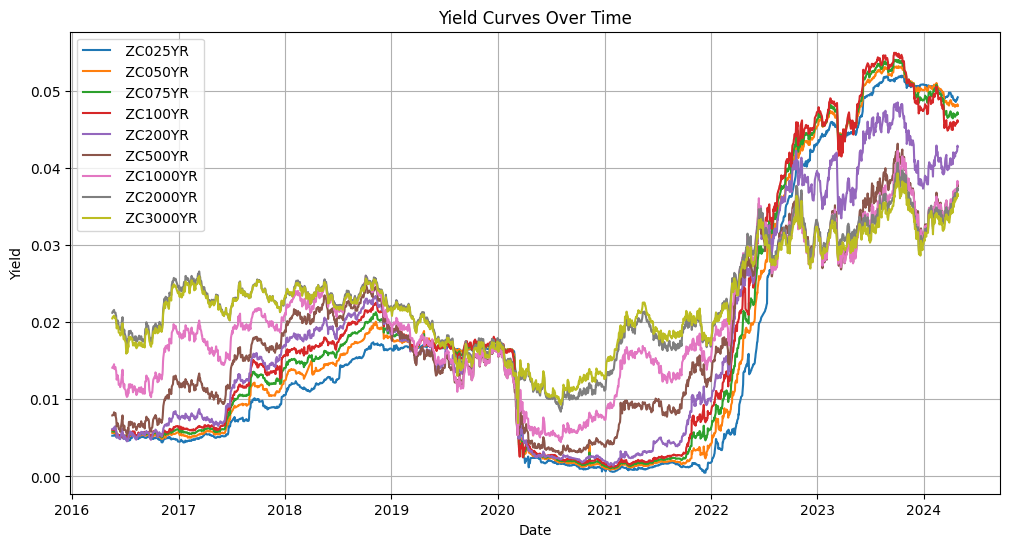

In [95]:
#Visualization of yield curves to look for anamolies.

yield_cols = train.columns.drop("Date")

plt.figure(figsize=(12, 6))

for col in yield_cols:
    plt.plot(train['Date'], train[col], label=col)

plt.xlabel('Date')
plt.ylabel('Yield')
plt.title('Yield Curves Over Time')
plt.legend()
plt.grid(True)
plt.show()

#There is a good sign of correlation between the data so we can say that we can use the 3M data in the CIR model.

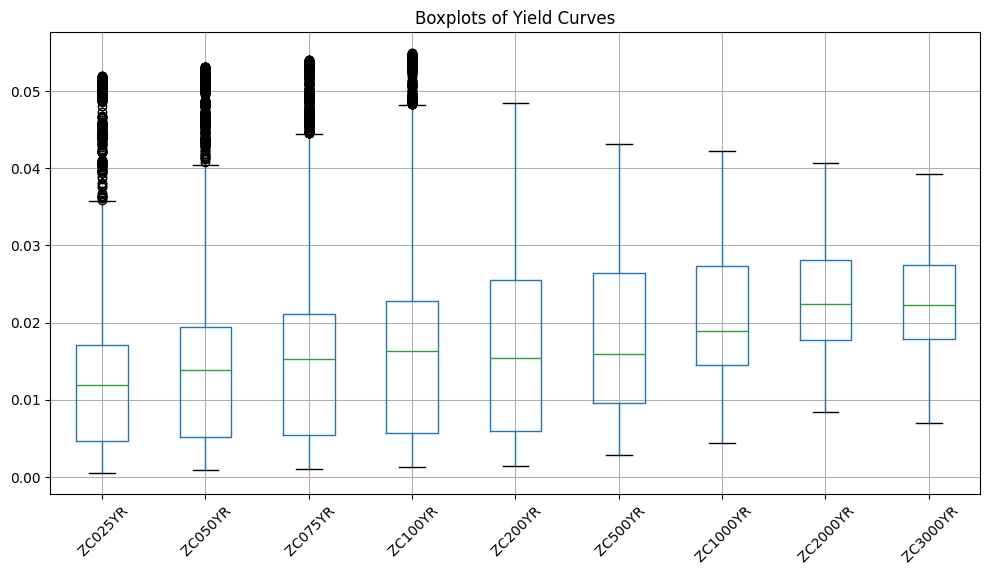

In [96]:
train[yield_cols].boxplot(figsize=(12, 6))
plt.title('Boxplots of Yield Curves')
plt.xticks(rotation=45)
plt.show()

In [97]:
z_scores = np.abs(zscore(train[yield_cols]))

outlier_counts = (z_scores > 3).sum(axis = 0)

print("Number of Outliers (Z-Score > 3):")
print(outlier_counts)

# We don't have any significant outliers and that shown in the box plots are
# ideally real economic events rather than noise.

Number of Outliers (Z-Score > 3):
[0 0 0 0 0 0 0 0 0]


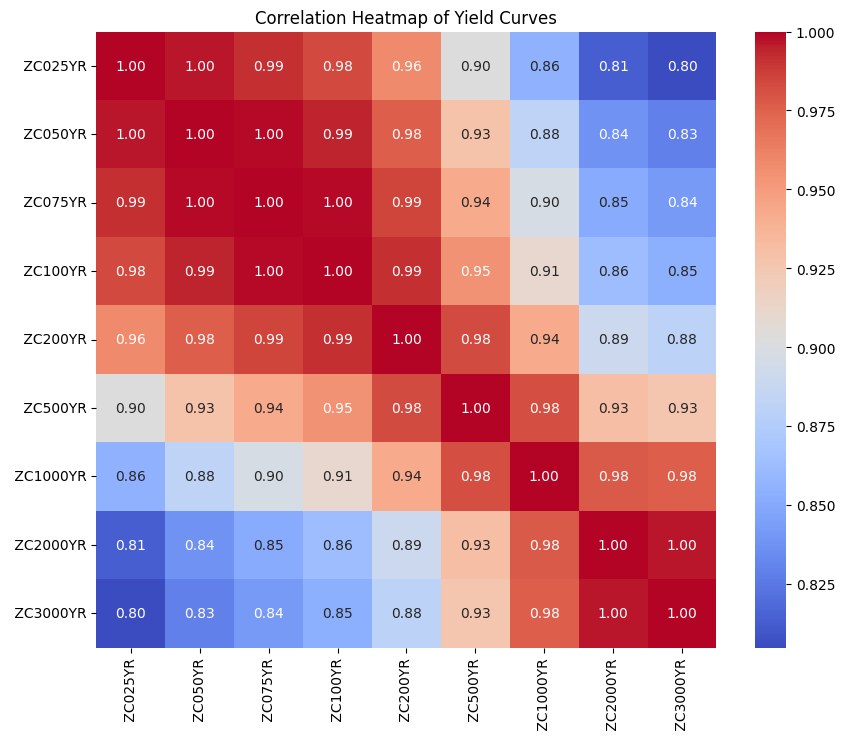

In [98]:
corr_matrix = train[yield_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Yield Curves')
plt.show()

The training dataset was examined for missing values, duplicate observations, invalid entries and outliers. No missing values or duplicate dates were found, and all yield series were positive, making them suitable for CIR modelling. Statistical summaries and visual inspections confirmed that the data was consistent and free from significant errors. Correlation analysis revealed strong relationships across maturities, indicating that the 3-month yield contains substantial information about the overall yield curve. Therefore, the dataset was deemed suitable for subsequent time-series calibration and stochastic interest-rate modelling.

In [99]:
# Autocorrelation
train[' ZC025YR'].autocorr()

# interest rates should have memory.

np.float64(0.9999012220660917)

In [100]:
# Stationarity (ADF test)
adfuller(train[' ZC025YR'])[1]

# Not Stationary

np.float64(0.9585540138274081)

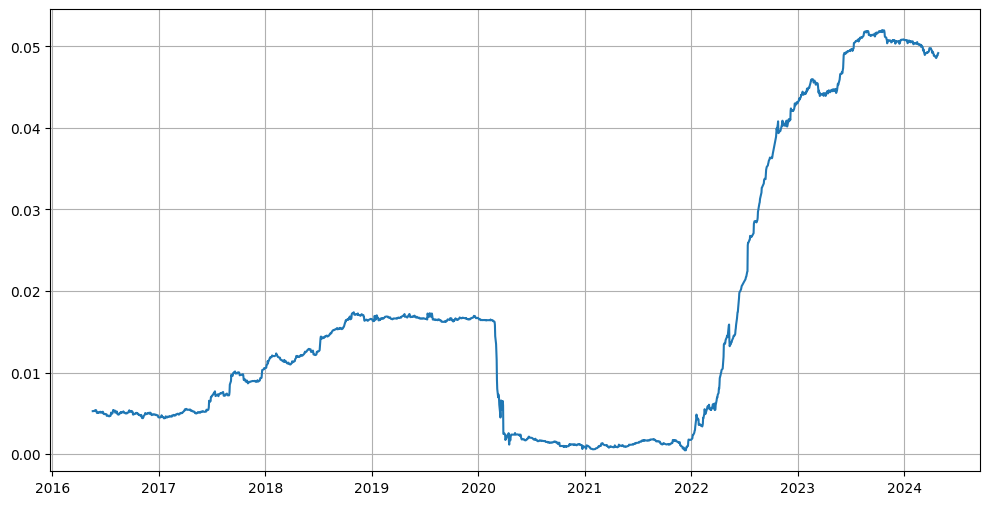

In [101]:
# Checking for Mean Reversion
plt.figure(figsize = (12,6))
plt.plot(train['Date'], train[' ZC025YR'])
plt.grid()
plt.show()

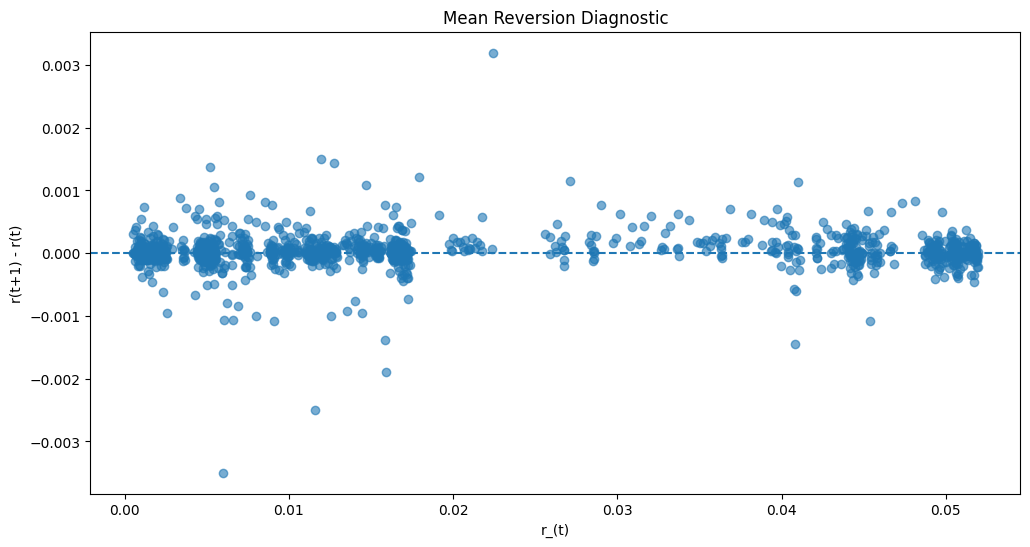


Mean Reversion Slope: 0.0007472739186562406


In [102]:
r_t = train[' ZC025YR'][:-1]
r_next = train[' ZC025YR'][1:]
dr = r_next.values - r_t.values
plt.figure(figsize = (12,6))
plt.scatter(r_t, dr, alpha = 0.6)
plt.axhline(0, linestyle = '--')
plt.xlabel('r_(t)')
plt.ylabel('r(t+1) - r(t)')
plt.title("Mean Reversion Diagnostic")
plt.show()

slope, intercept = np.polyfit(r_t, dr, 1)
print('')
print(f"Mean Reversion Slope: {slope}")

The daily mean-reversion signal is weak and difficult to detect directly from a simple $\Delta r_t$ vs $r_t$ regression. The estimated slope is close to zero, indicating that short-term dynamics are dominated by persistence and stochastic fluctuations rather than strong daily pull towards a long run mean.

<Figure size 1000x500 with 0 Axes>

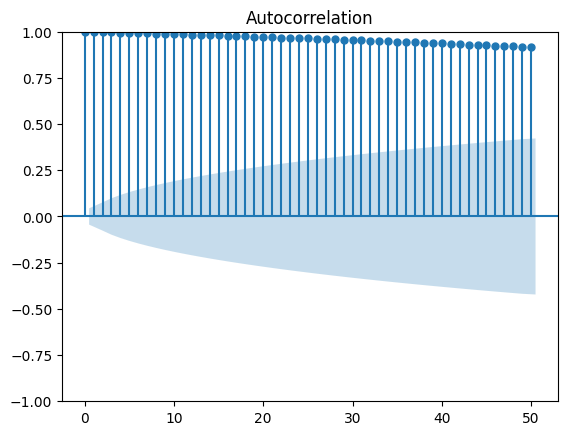

In [103]:
plt.figure(figsize=(10,5))
plot_acf(train[' ZC025YR'], lags=50)
plt.show()

The 3M yield exhibits extremely strong autocorrelation, with the correlations remaining above 0.8 even after 50 lags. This indicates substantial persistence and temporal dependence, which are characteristic features of interest-rate processes. Although the ADF test suggests non-stationarity over the full sample period, this is likely influenced by significant market regime changes. Overall, the series demonstrates sufficient structure and persistence to support stochastic interest-rate model callibration

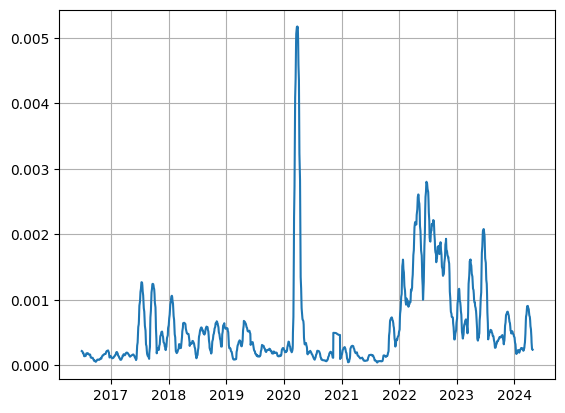

In [104]:
# Rolling Volatility, to check if the process is truly stochastic.
rolling_vol = train[' ZC050YR'].rolling(30).std()
plt.plot(train['Date'], rolling_vol)
plt.grid()
plt.show()

Preprocessing the test_data_3M

In [105]:
print(test_3M.shape)
print("--"*40)
print(test_3M.head())
print("--"*40)
print(test_3M.info())

(495, 2)
--------------------------------------------------------------------------------
         Date   ZC025YR
0  2024-04-29  0.049144
1  2024-04-30  0.049156
2  2024-05-01  0.049100
3  2024-05-02  0.048921
4  2024-05-03  0.048633
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      495 non-null    object 
 1    ZC025YR  495 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB
None


In [106]:
test_3M['Date'] = pd.to_datetime(test_3M['Date'])
test_3M['Date'].duplicated().sum()
#No duplicates

np.int64(0)

In [107]:
print(test_3M.isnull().sum())

Date        0
 ZC025YR    0
dtype: int64


In [108]:
print((test_3M[' ZC025YR']<0).sum())

0


In [109]:
test_3M.describe()

,Date,ZC025YR
count,495,495.000000
mean,2025-04-26 16:29:05.454545408,0.030417
min,2024-04-29 00:00:00,0.021697
25%,2024-10-26 12:00:00,0.023063
50%,2025-04-25 00:00:00,0.026580
75%,2025-10-27 12:00:00,0.035119
max,2026-04-29 00:00:00,0.049156
std,NaN,0.008508


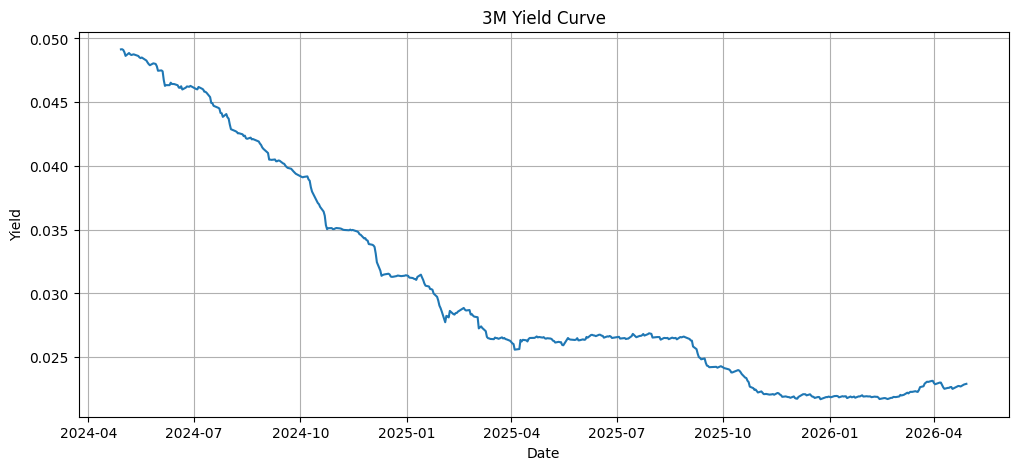

In [110]:
plt.figure(figsize=(12, 5))
plt.plot(test_3M['Date'], test_3M[' ZC025YR'])
plt.grid()
plt.title('3M Yield Curve')
plt.xlabel('Date')
plt.ylabel('Yield')
plt.show()

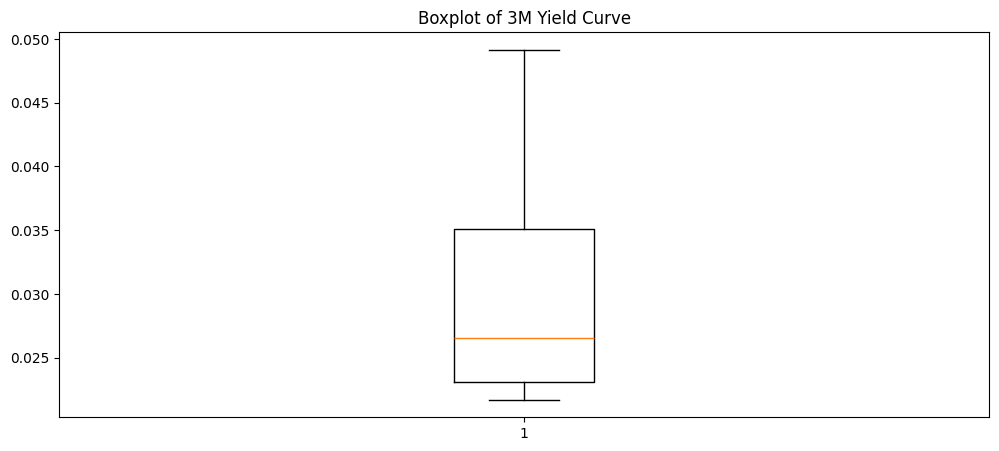

In [111]:
plt.figure(figsize=(12, 5))
plt.boxplot(test_3M[' ZC025YR'])
plt.title('Boxplot of 3M Yield Curve')
plt.show()

In [112]:
z = np.abs(zscore(test_3M[' ZC025YR']))
print('OUtliers (z >|3|): ', (z>3).sum())

OUtliers (z >|3|):  0


In [113]:
test_3M[' ZC025YR'].autocorr()

np.float64(0.9998250884950372)

In [114]:
print(adfuller(test_3M[' ZC025YR'])[1])

0.013116586056918886


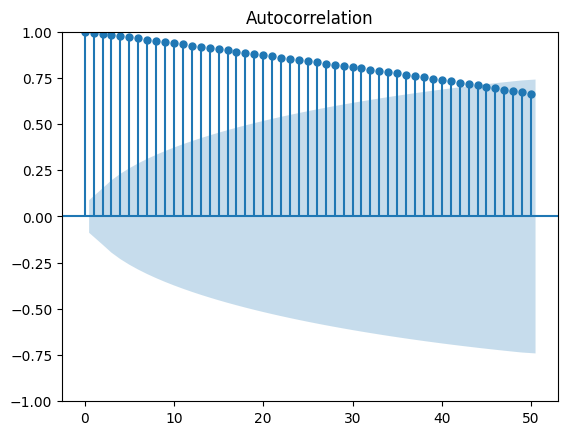

In [115]:
plot_acf(test_3M[' ZC025YR'], lags=50)
plt.show()

The 3-month yield series is clean, positive, highly persistent, free from significant anomalies, and exhibits statistical properties consistent with interest-rate dynamics, consequently, the dataset is considered suitable as input for CIR model forecasting and subsequent yield curve prediction.

# Base CIR Model Implementation and Calibration

The short-term interest rate was modeled using the Cox-Ingersoll-Ross (CIR) process:

$$
dr_t=\kappa(\theta-r_t)dt+\sigma\sqrt{r_t}dW_t
$$

Here, $r_t$ denotes the short rate, $\kappa$ is the speed of mean reversion, $\theta$ is the long-run equilibrium rate, $\sigma$ is the volatility parameter, and $W_t$ is a standard Brownian motion.

The drift term

$$
\kappa(\theta-r_t)
$$

forces the interest rate to revert toward the long-run mean $\theta$, while the diffusion term

$$
\sigma\sqrt{r_t}dW_t
$$

introduces stochastic fluctuations. The square-root diffusion ensures that volatility increases with the level of interest rates and helps maintain positivity of the process.

## Maximum Likelihood Calibration

Since the data are observed at discrete daily intervals, the CIR process was approximated using its exact conditional moments. Under the CIR model, the conditional distribution of the next observation is approximated as

$$
r_{t+\Delta t}\mid r_t
\sim
N(\mu_t,v_t),
$$

with conditional mean

$$
\mu_t=\theta+(r_t-\theta)e^{-\kappa\Delta t},
$$

and conditional variance

$$
v_t =\frac{\sigma^2}{\kappa}
r_t e^{-\kappa\Delta t}
(1-e^{-\kappa\Delta t})
+
\frac{\theta\sigma^2}{2\kappa}
(1-e^{-\kappa\Delta t})^2.
$$

For an observed time series

$$
r_1,r_2,\ldots,r_n,
$$

the likelihood is constructed as the product of all one-step transition densities:

$$
L(\kappa,\theta,\sigma)= \prod_{t=1}^{n-1}
p(r_{t+1}\mid r_t).
$$

Using the Gaussian approximation,

$$
p(r_{t+1}\mid r_t) = \frac{1}{\sqrt{2\pi v_t}}
\exp\left(
-\frac{(r_{t+1}-\mu_t)^2}{2v_t}
\right).
$$

Taking logarithms gives the log-likelihood function

$$
\log L = \sum_{t=1}^{n-1}
\left[
-\frac{1}{2}\log(2\pi v_t)
-\frac{1}{2}
\frac{(r_{t+1}-\mu_t)^2}{v_t}
\right].
$$

The optimal parameter estimates are obtained by maximizing $\log L$ using the L-BFGS-B optimization algorithm with positivity constraints imposed on all parameters.

## Calibrated Parameters

The calibration procedure converged successfully and produced the following parameter estimates:

$$
\hat{\kappa}=0.01295,
$$

$$
\hat{\theta}=0.18926,
$$

$$
\hat{\sigma}=0.04128.
$$

The relatively small value of $\hat{\kappa}$ indicates slow mean reversion and strong persistence of interest-rate shocks, consistent with the high autocorrelation observed during exploratory data analysis.

The estimated long-run mean $\hat{\theta}$ is substantially higher than the observed rate range. This occurs because the data exhibit very slow mean reversion, making the parameter $\theta$ weakly identified over the available sample period.

## Feller Condition

To ensure positivity of the CIR process, the Feller condition was checked:

$$
2\kappa\theta>\sigma^2.
$$

Substituting the calibrated parameters gives

$$
2\hat{\kappa}\hat{\theta}=0.00490,
$$

and

$$
\hat{\sigma}^2=0.00170.
$$

Since

$$
0.00490>0.00170,
$$

the Feller condition is satisfied, implying that the calibrated CIR process remains strictly positive.

## In-Sample Validation

Using the calibrated parameters, one-step-ahead fitted rates were generated from the conditional expectation

$$
\hat r_{t+1} = \hat\theta
+
(r_t-\hat\theta)e^{-\hat\kappa\Delta t}.
$$

The fitted series closely tracked the observed training data. The resulting error metrics were

$$
\text{RMSE}=0.000235,
$$

and

$$
\text{MAE}=0.000109.
$$

Residuals were centered around zero with no significant systematic bias, indicating that the CIR model successfully captures the dominant mean-reverting dynamics of the short-rate process.

Overall, the calibrated CIR model provides a mathematically consistent representation of the short-rate dynamics and serves as the baseline model for the subsequent yield-curve reconstruction task.


In [116]:
r = train[" ZC025YR"].values

dt = 1/252


def cir_qmle_negloglik(params, r, dt):

    kappa, theta, sigma = params

    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e12

    r_t = r[:-1]
    r_next = r[1:]

    exp_term = np.exp(-kappa*dt)

    mean = theta + (r_t-theta)*exp_term

    var = (
        (sigma**2/kappa)
        * r_t
        * exp_term
        * (1-exp_term)
        +
        (theta*sigma**2/(2*kappa))
        * (1-exp_term)**2
    )

    var = np.maximum(var,1e-12)

    logL = np.sum(
        -0.5*np.log(2*np.pi*var)
        -0.5*((r_next-mean)**2)/var
    )

    return -logL

initial_guess = [
    0.5,
    np.mean(r),
    0.05
]

result = minimize(
    cir_qmle_negloglik,
    initial_guess,
    args=(r,dt),
    method='L-BFGS-B',
    bounds=[
        (1e-4,20),
        (1e-5,0.2),
        (1e-4,1.0)
    ]
)

kappa_hat, theta_hat, sigma_hat = result.x

print("kappa =", kappa_hat)
print("theta =", theta_hat)
print("sigma =", sigma_hat)

print(result)

lhs = 2 * kappa_hat * theta_hat
rhs = sigma_hat**2

print("2*kappa*theta =", lhs)
print("sigma^2 =", rhs)

if lhs > rhs:
    print("Feller condition satisfied")
else:
    print("Feller condition violated")

kappa = 0.01295008139695302
theta = 0.189257389151635
sigma = 0.041283465927324396
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -13616.44006186644
        x: [ 1.295e-02  1.893e-01  4.128e-02]
      nit: 27
      jac: [-2.137e+01 -2.522e+00 -9.973e+01]
     nfev: 164
     njev: 41
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
2*kappa*theta = 0.004901797188976973
sigma^2 = 0.0017043245589725543
Feller condition satisfied


CIR In-Sample Validation
RMSE : 0.000235
MAE  : 0.000109

Residual Statistics
------------------------------
Mean Residual : 0.00001335
Std Residual  : 0.00023425
Min Residual  : -0.00350782
Max Residual  : 0.00318873


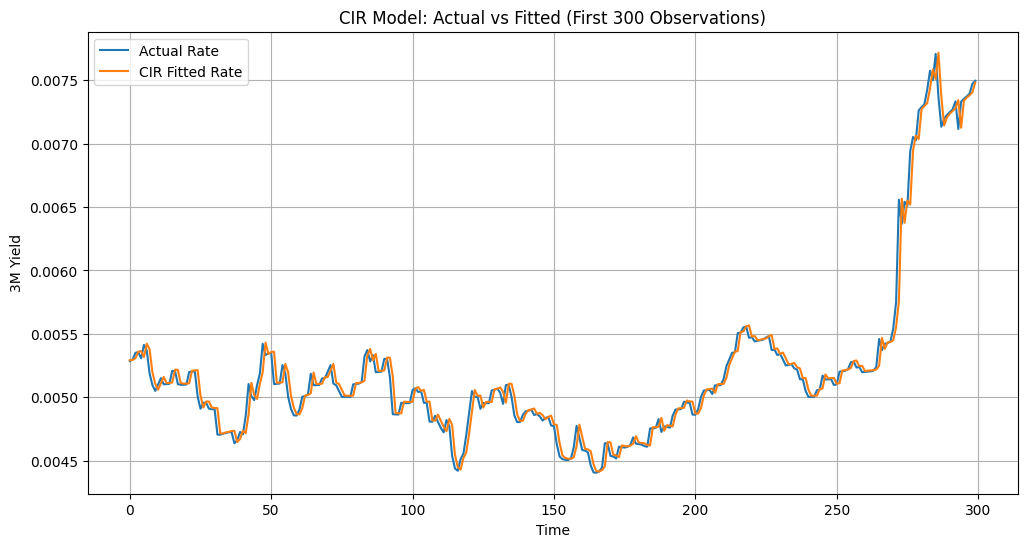

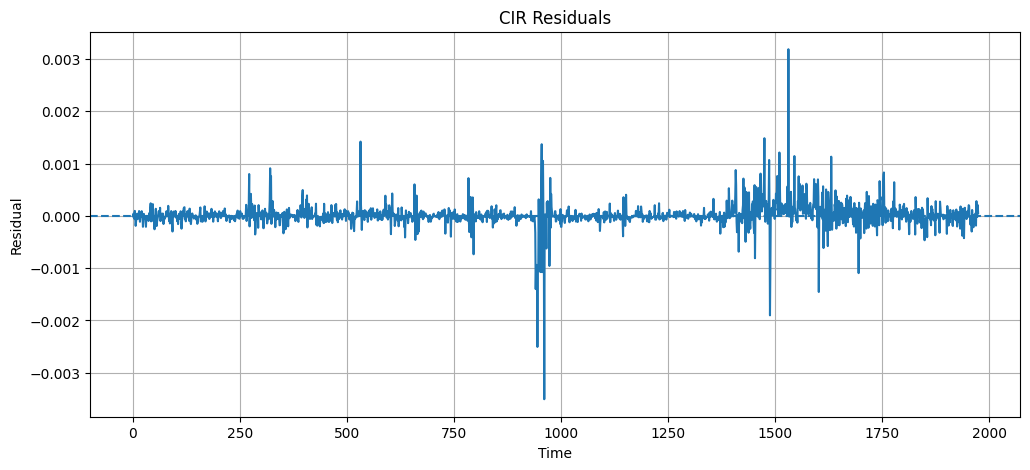

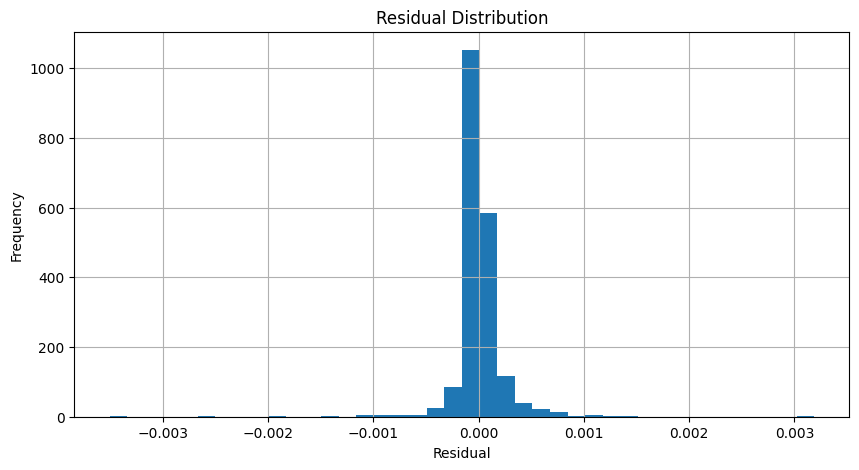

In [117]:
# =========================
# CIR In-Sample Validation
# =========================

# Calibrated parameters
kappa_hat = 0.01295008139695302
theta_hat = 0.189257389151635
sigma_hat = 0.041283465927324396

# Data
r = train[" ZC025YR"].values
dt = 1/252

# Current and next observations
r_t = r[:-1]
r_next = r[1:]

# CIR conditional mean
r_pred = (
    theta_hat
    + (r_t - theta_hat)
    * np.exp(-kappa_hat * dt)
)

# =========================
# Error Metrics
# =========================

rmse = np.sqrt(
    mean_squared_error(
        r_next,
        r_pred
    )
)

mae = mean_absolute_error(
    r_next,
    r_pred
)

print("="*50)
print("CIR In-Sample Validation")
print("="*50)
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")

# =========================
# Residual Analysis
# =========================

residuals = r_next - r_pred

print("\nResidual Statistics")
print("-"*30)
print(f"Mean Residual : {np.mean(residuals):.8f}")
print(f"Std Residual  : {np.std(residuals):.8f}")
print(f"Min Residual  : {np.min(residuals):.8f}")
print(f"Max Residual  : {np.max(residuals):.8f}")

# =========================
# Actual vs CIR Fitted
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    r_next[:300],
    label="Actual Rate"
)

plt.plot(
    r_pred[:300],
    label="CIR Fitted Rate"
)

plt.title("CIR Model: Actual vs Fitted (First 300 Observations)")
plt.xlabel("Time")
plt.ylabel("3M Yield")
plt.legend()
plt.grid(True)

plt.show()

# =========================
# Residual Plot
# =========================

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("CIR Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)

plt.show()

# =========================
# Residual Histogram
# =========================

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=40
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### Why Maximum Likelihood Estimation?

The objective of calibration is to estimate the unknown CIR parameters $ (\kappa,\theta,\sigma) $ from historical interest-rate observations. Maximum Likelihood Estimation (MLE) was chosen because the CIR model specifies a probabilistic law governing the evolution of interest rates through its transition distribution

$$
p(r_{t+\Delta t}\mid r_t;\kappa,\theta,\sigma).
$$

This transition distribution describes the probability of observing the next short rate given the current short rate and a particular set of model parameters.

For a historical time series

$$
r_1,r_2,\ldots,r_n,
$$

the likelihood function measures how probable the observed data are under a given parameter set:

$$
L(\kappa,\theta,\sigma) = \prod_{t=1}^{n-1}
p(r_{t+1}\mid r_t).
$$

Maximum Likelihood Estimation selects the parameter values that maximize this likelihood, i.e., the parameters that make the observed interest-rate path most probable under the CIR model:

$$
(\hat{\kappa},\hat{\theta},\hat{\sigma}) = \arg\max_{\kappa,\theta,\sigma}
L(\kappa,\theta,\sigma).
$$

MLE is particularly suitable for CIR calibration because:

* It directly utilizes the stochastic structure of the CIR process.
* It incorporates both the drift and volatility dynamics of the model.
* It produces statistically efficient parameter estimates under regularity conditions.
* It is the standard calibration technique used in academic literature and fixed-income modelling.

Therefore, MLE provides a principled framework for estimating the CIR parameters from historical yield data while remaining fully consistent with the probabilistic assumptions of the model.


# Yield Curve Reconstruction and Out-of-Sample Prediction

In [118]:
# ==========================
# CIR Parameters
# ==========================

kappa = 0.01295008139695302
theta = 0.189257389151635
sigma = 0.041283465927324396

# ==========================
# Load Test Data
# ==========================

test3m = pd.read_csv("test_data_3M.csv")
test = pd.read_csv("test_data.csv")

# ==========================
# CIR Yield Function
# ==========================

def cir_yield(r_t, T, kappa, theta, sigma):

    gamma = np.sqrt(
        kappa**2 + 2*sigma**2
    )

    B = (
        2*(np.exp(gamma*T)-1)
        /
        (
            (kappa+gamma)*(np.exp(gamma*T)-1)
            + 2*gamma
        )
    )

    A = (
        (
            2*gamma*np.exp(
                (kappa+gamma)*T/2
            )
        )
        /
        (
            (kappa+gamma)*(np.exp(gamma*T)-1)
            + 2*gamma
        )
    ) ** (
        2*kappa*theta/sigma**2
    )

    P = A*np.exp(-B*r_t)

    y = -np.log(P)/T

    return y

# ==========================
# Predict Entire Test Set
# ==========================

pred_6m = []
pred_9m = []
pred_1y = []
pred_2y = []

for r_t in test3m[" ZC025YR"]:

    pred_6m.append(
        cir_yield(
            r_t,
            0.50,
            kappa,
            theta,
            sigma
        )
    )

    pred_9m.append(
        cir_yield(
            r_t,
            0.75,
            kappa,
            theta,
            sigma
        )
    )

    pred_1y.append(
        cir_yield(
            r_t,
            1.00,
            kappa,
            theta,
            sigma
        )
    )

    pred_2y.append(
        cir_yield(
            r_t,
            2.00,
            kappa,
            theta,
            sigma
        )
    )

# ==========================
# Evaluation
# ==========================

targets = {
    "6M": (" ZC050YR", pred_6m),
    "9M": (" ZC075YR", pred_9m),
    "1Y": (" ZC100YR", pred_1y),
    "2Y": (" ZC200YR", pred_2y)
}

print("="*60)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*60)

for label, (col, pred) in targets.items():

    actual = test[col]

    r2 = r2_score(actual, pred)

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    mae = mean_absolute_error(
        actual,
        pred
    )

    print(f"\n{label}")
    print("-"*20)
    print("R²   =", round(r2, 4))
    print("RMSE =", round(rmse, 6))
    print("MAE  =", round(mae, 6))

OUT-OF-SAMPLE PERFORMANCE

6M
--------------------
R²   = 0.9776
RMSE = 0.001181
MAE  = 0.00094

9M
--------------------
R²   = 0.9054
RMSE = 0.00222
MAE  = 0.001764

1Y
--------------------
R²   = 0.7682
RMSE = 0.003168
MAE  = 0.002503

2Y
--------------------
R²   = -0.5743
RMSE = 0.005868
MAE  = 0.004571


In [119]:
# ==========================
# Prediction DataFrame
# ==========================

pred_data = pd.DataFrame()

# Date column
pred_data["Date"] = test["Date"]

# Input 3M rate
pred_data[" ZC025YR"] = test3m[" ZC025YR"]

# CIR Predictions
pred_data[" ZC050YR"] = pred_6m
pred_data[" ZC075YR"] = pred_9m
pred_data[" ZC100YR"] = pred_1y
pred_data[" ZC200YR"] = pred_2y

# Save
pred_data.to_csv(
    "pred_data.csv",
    index=False
)

print("pred_data.csv saved successfully")
print(pred_data.head())

pred_data.csv saved successfully
         Date   ZC025YR   ZC050YR   ZC075YR   ZC100YR   ZC200YR
0  2024-04-29  0.049144  0.049594  0.049815  0.050034  0.050888
1  2024-04-30  0.049156  0.049606  0.049827  0.050046  0.050900
2  2024-05-01  0.049100  0.049550  0.049771  0.049990  0.050844
3  2024-05-02  0.048921  0.049371  0.049592  0.049812  0.050667
4  2024-05-03  0.048633  0.049084  0.049306  0.049526  0.050383


In [120]:
# ==========================
# Actual vs Predicted
# ==========================

comparison = pd.DataFrame()

comparison["Date"] = test["Date"]

comparison["Actual_3M"] = test[" ZC025YR"]

comparison["Actual_6M"] = test[" ZC050YR"]
comparison["Pred_6M"] = pred_6m

comparison["Actual_9M"] = test[" ZC075YR"]
comparison["Pred_9M"] = pred_9m

comparison["Actual_1Y"] = test[" ZC100YR"]
comparison["Pred_1Y"] = pred_1y

comparison["Actual_2Y"] = test[" ZC200YR"]
comparison["Pred_2Y"] = pred_2y

comparison.to_csv(
    "comparison_CIR.csv",
    index=False
)

print("comparison_CIR.csv saved successfully")

comparison_CIR.csv saved successfully


# Yield Curve Reconstruction and Out-of-Sample Prediction

Following calibration of the CIR model on the training dataset, the estimated parameters

$$
\hat{\kappa}=0.01295,\qquad
\hat{\theta}=0.18926,\qquad
\hat{\sigma}=0.04128
$$

were used to reconstruct the yield curve during the test period.

According to the project constraints, the prediction algorithm was only allowed to use the observed 3-Month (3M) yield as a proxy for the instantaneous short rate $r_t$. No information from longer maturities was used during prediction.

## CIR Bond Pricing Formula

Under the CIR framework, the price of a zero-coupon bond with maturity $T$ is given by

$$
P(t,T)=A(T)\exp[-B(T)r_t],
$$

where

$$
\gamma=\sqrt{\kappa^2+2\sigma^2},
$$

$$
B(T)=
\frac{
2\left(e^{\gamma T}-1\right)
}
{
(\kappa+\gamma)\left(e^{\gamma T}-1\right)+2\gamma
},
$$

and

$$
A(T)=
\left[
\frac{
2\gamma e^{(\kappa+\gamma)T/2}
}
{
(\kappa+\gamma)\left(e^{\gamma T}-1\right)+2\gamma
}
\right]^{\frac{2\kappa\theta}{\sigma^2}}.
$$

The continuously compounded yield corresponding to maturity $T$ is then

$$
y(t,T) = -\frac{\ln P(t,T)}{T}.
$$

For each day in the test set, the observed 3M yield was treated as the current short rate $r_t$, and the above formulas were used to generate theoretical yields for the 6M, 9M, 1Y, and 2Y maturities.

## Out-of-Sample Performance

The reconstructed yields were compared against the actual yields contained in the held-out test dataset using the coefficient of determination ($R^2$), root mean squared error (RMSE), and mean absolute error (MAE).

| Maturity | R²      | RMSE     | MAE      |
| -------- | ------- | -------- | -------- |
| 6M       | 0.9776  | 0.001181 | 0.000940 |
| 9M       | 0.9054  | 0.002220 | 0.001764 |
| 1Y       | 0.7682  | 0.003168 | 0.002503 |
| 2Y       | -0.5743 | 0.005868 | 0.004571 |

## Analysis of Results

The CIR model achieved excellent predictive performance for short maturities. The 6M yield was reconstructed with an out-of-sample $R^2$ of 0.9776, while the 9M yield achieved an $R^2$ of 0.9054. In both cases, the predicted yields closely followed the observed market yields throughout the test period.

Prediction accuracy deteriorated as maturity increased. For the 1Y maturity, the model still captured the general downward trend in interest rates but exhibited noticeable deviations from the observed curve, reducing the $R^2$ to 0.7682.

The largest deterioration occurred for the 2Y maturity, where the model systematically overestimated yields over significant portions of the sample period. The resulting negative $R^2$ indicates that the model performed worse than a simple prediction based on the sample mean of the observed 2Y yield.

The prediction plots reveal that the CIR model successfully captures the overall level and long-term trend of the yield curve but struggles to reproduce the dynamics of longer maturities.

## Interpretation

This behaviour is consistent with the theoretical structure of the CIR model. The CIR framework is a one-factor short-rate model in which the entire term structure is driven by a single state variable, namely the short rate $r_t$.

Consequently, short maturities remain strongly linked to the current short rate and can be reconstructed accurately. Longer maturities, however, depend on additional market factors such as future monetary policy expectations, inflation expectations, and term premia. These effects are not represented within a single-factor CIR framework.

Therefore, while the calibrated CIR model provides a strong reconstruction of the short end of the yield curve, its predictive power decreases as maturity increases. This limitation motivates the consideration of more sophisticated extensions, such as two-factor CIR models or time-dependent parameter models, which can better capture the shape and dynamics of the full yield curve.


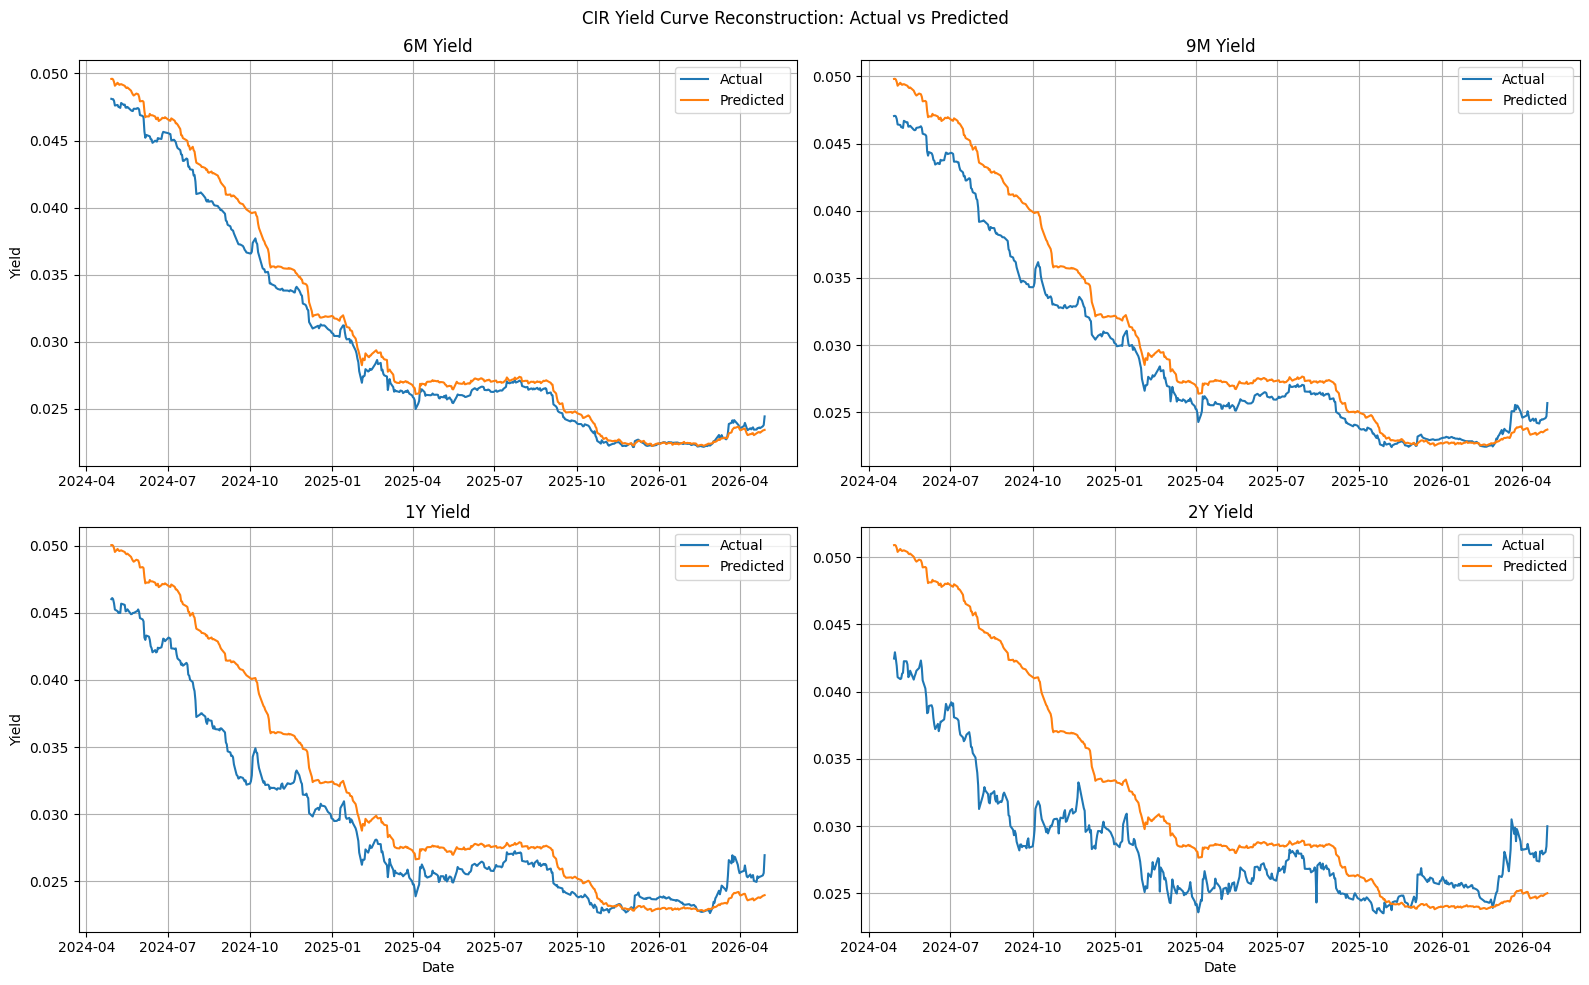

In [121]:
dates = pd.to_datetime(test["Date"])

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

# 6M
axes[0,0].plot(
    dates,
    test[" ZC050YR"],
    label="Actual"
)

axes[0,0].plot(
    dates,
    pred_6m,
    label="Predicted"
)

axes[0,0].set_title("6M Yield")
axes[0,0].set_ylabel("Yield")
axes[0,0].grid(True)
axes[0,0].legend()

# 9M
axes[0,1].plot(
    dates,
    test[" ZC075YR"],
    label="Actual"
)

axes[0,1].plot(
    dates,
    pred_9m,
    label="Predicted"
)

axes[0,1].set_title("9M Yield")
axes[0,1].grid(True)
axes[0,1].legend()

# 1Y
axes[1,0].plot(
    dates,
    test[" ZC100YR"],
    label="Actual"
)

axes[1,0].plot(
    dates,
    pred_1y,
    label="Predicted"
)

axes[1,0].set_title("1Y Yield")
axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("Yield")
axes[1,0].grid(True)
axes[1,0].legend()

# 2Y
axes[1,1].plot(
    dates,
    test[" ZC200YR"],
    label="Actual"
)

axes[1,1].plot(
    dates,
    pred_2y,
    label="Predicted"
)

axes[1,1].set_title("2Y Yield")
axes[1,1].set_xlabel("Date")
axes[1,1].grid(True)
axes[1,1].legend()

plt.suptitle(
    "CIR Yield Curve Reconstruction: Actual vs Predicted"
)

plt.tight_layout()

plt.show()

In [122]:
actual_all = np.concatenate([
    test[" ZC050YR"].values,
    test[" ZC075YR"].values,
    test[" ZC100YR"].values,
    test[" ZC200YR"].values
])

pred_all = np.concatenate([
    pred_6m,
    pred_9m,
    pred_1y,
    pred_2y
])

combined_r2 = r2_score(
    actual_all,
    pred_all
)

print("Combined Out-of-Sample R² =", combined_r2)

overall_rmse = np.sqrt(
    mean_squared_error(
        actual_all,
        pred_all
    )
)

overall_mae = mean_absolute_error(
    actual_all,
    pred_all
)

print("Overall RMSE =", overall_rmse)
print("Overall MAE  =", overall_mae)

Combined Out-of-Sample R² = 0.7182680463415672
Overall RMSE = 0.0035637361224426563
Overall MAE  = 0.0024446371725869876


## Conclusion

The calibrated CIR model successfully reconstructed the short end of the yield curve using only the observed 3M rate and the parameters estimated from the training dataset. The model achieved strong predictive performance for the 6M and 9M maturities, with out-of-sample $R^2$ values of 0.9776 and 0.9054 respectively. However, prediction accuracy deteriorated for longer maturities, particularly for the 2Y yield, where the model systematically overestimated observed market rates.

When evaluated across all maturities simultaneously, the model achieved a combined out-of-sample score of

$$
R^2_{OOS}=0.7183,
$$

with

$$
\text{RMSE}=0.00356,
$$

and

$$
\text{MAE}=0.00244.
$$

Although the CIR framework captures the dominant level dynamics of the term structure, the results indicate that a single-factor short-rate model is insufficient to fully explain the cross-sectional variation of yields at longer maturities.

These findings are consistent with the theoretical limitations of the CIR model. Since the entire yield curve is driven by a single state variable, the model cannot adequately capture additional sources of variation such as changes in slope, curvature, market expectations, or macroeconomic shocks. Consequently, while the CIR model serves as a robust baseline, further improvements are required to achieve the predictive accuracy target specified in the project.

This motivates the investigation of advanced extensions in the next section, where more flexible frameworks such as Two-Factor CIR models, Jump-Diffusion models, and CIR++ models will be explored and evaluated to determine whether they provide meaningful improvements in out-of-sample yield curve reconstruction.


##Model Improvement and Extensions

The results obtained in Section 5.3 demonstrate that the calibrated single-factor CIR model is capable of capturing the broad evolution of the yield curve using only the 3-month Treasury yield as input. The model achieved a combined out-of-sample coefficient of determination of approximately (R^2 = 0.72), indicating that a significant fraction of the variation in longer-maturity yields can be explained through the dynamics of a single short-rate factor. However, the reconstruction errors observed across maturities reveal several important limitations of the classical CIR framework.

The fundamental assumption underlying the CIR model is that the entire term structure of interest rates is driven by a single latent factor. While this assumption provides analytical tractability and economic interpretability, it restricts the model's ability to represent changes in the shape of the yield curve. In practice, yield curves exhibit multiple sources of variation, including changes in the overall level of rates, variations in the slope between short- and long-term yields, and fluctuations in the curvature of the term structure. A single-factor model is unable to capture these effects simultaneously.

The empirical results obtained in Section 5.3 support this observation. Although the CIR model produced satisfactory predictions for shorter maturities, its performance deteriorated as maturity increased. In particular, the model struggled to reproduce the dynamics of the long end of the yield curve, suggesting that additional state variables are required to describe the evolution of market expectations across maturities.

To address these limitations, we investigate a sequence of multi-factor extensions. Rather than assuming that the entire yield curve is governed by a single short-rate process, the extended models decompose the term structure into several economically meaningful factors. These factors are designed to capture distinct aspects of yield-curve behaviour, including the overall level of interest rates and the relative steepness of the curve.

The objective of this section is therefore twofold. First, we evaluate whether introducing additional factors leads to measurable improvements in out-of-sample predictive performance. Second, we examine the extent to which increasingly rich factor structures can overcome the limitations of the baseline CIR model while remaining computationally tractable.

We begin by constructing a two-factor level-slope model and subsequently develop a more flexible three-factor affine extension. The predictive performance of these models is then compared against the baseline CIR framework using the same out-of-sample evaluation methodology employed throughout this study.


Train shape: (1976, 10)
Test shape : (495, 6)

Factor Means
Level = 0.016698838967611332
Slope = 0.0013639584008097168

VASICEK PARAMETERS
kappa = 0.7669151692680358
theta = 0.00016142076594319606
sigma = 0.007069785000291235

H shape = (5, 2)
d shape = (5,)

X_test shape = (495, 2)

Saved pred_data_two_factor.csv

TWO FACTOR MODEL

 ZC050YR
--------------------
R²   = 0.9672
RMSE = 0.001426
MAE  = 0.001115

 ZC075YR
--------------------
R²   = 0.8916
RMSE = 0.002378
MAE  = 0.001827

 ZC100YR
--------------------
R²   = 0.7561
RMSE = 0.00325
MAE  = 0.002482

 ZC200YR
--------------------
R²   = 0.3658
RMSE = 0.003725
MAE  = 0.003182

COMBINED PERFORMANCE
Combined R² = 0.8218521349260345
Overall RMSE = 0.002833856121339451
Overall MAE = 0.0021516547782781024


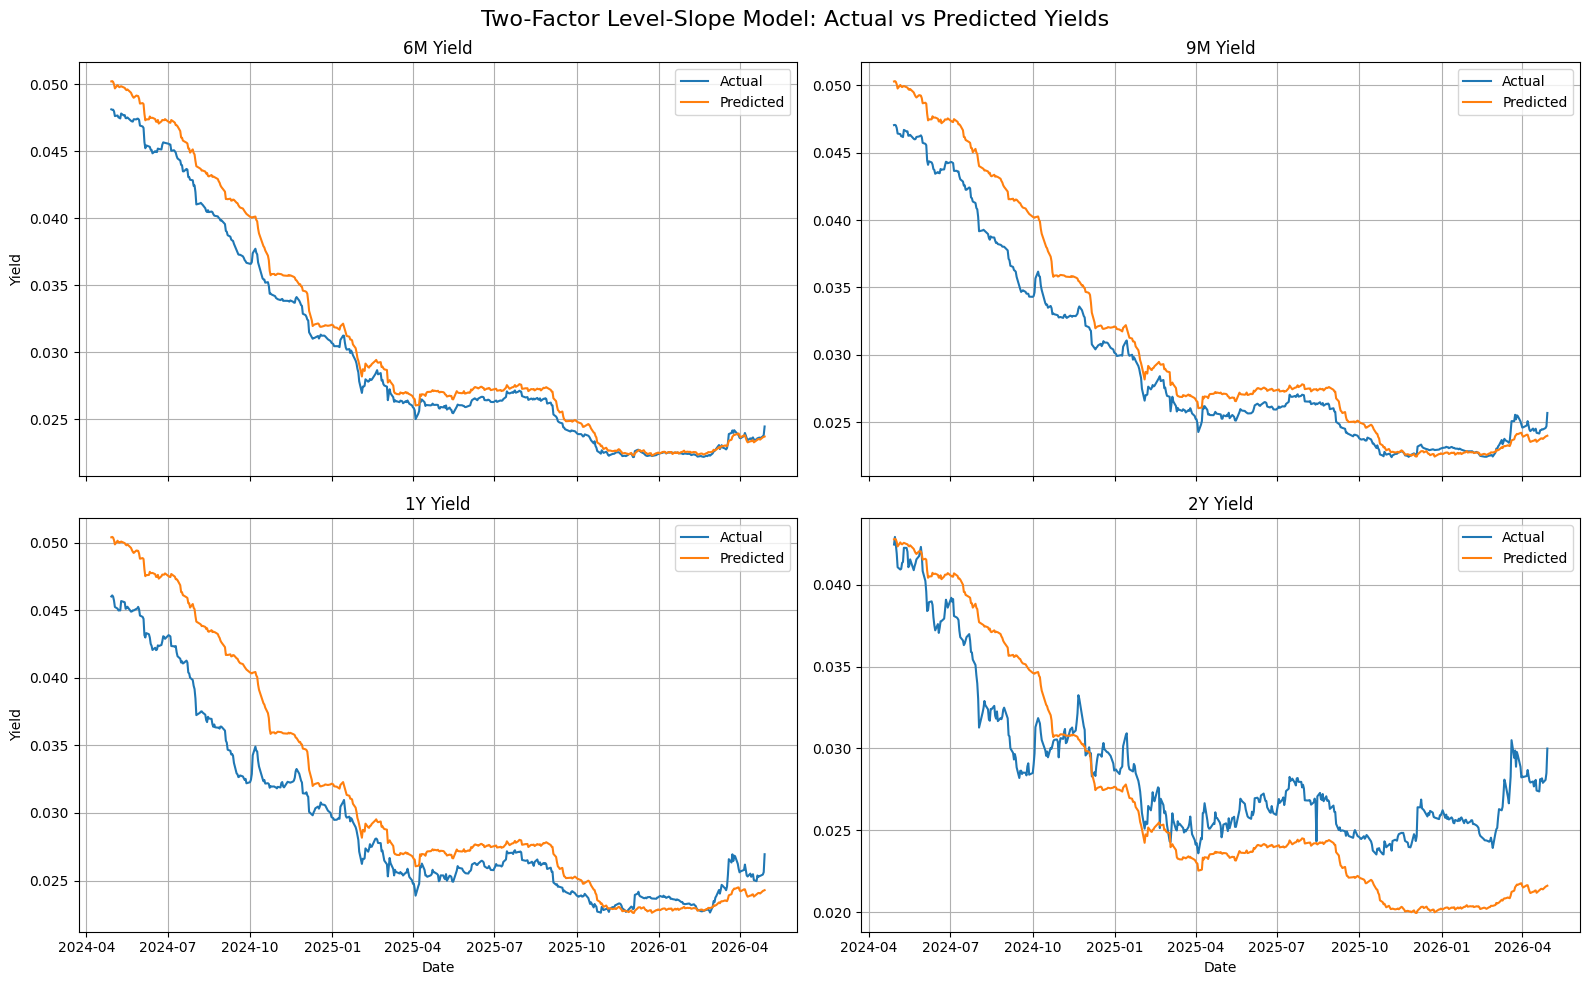

In [123]:
# ============================================================
# TWO FACTOR LEVEL-SLOPE MODEL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ============================================================
# LOAD DATA
# ============================================================

train = pd.read_csv("train_data.csv")

test3m = pd.read_csv("test_data_3M.csv")

test = pd.read_csv("test_data.csv")

yield_cols = [
    " ZC025YR",
    " ZC050YR",
    " ZC075YR",
    " ZC100YR",
    " ZC200YR"
]

print("Train shape:", train.shape)
print("Test shape :", test.shape)

# ============================================================
# FACTORS
# ============================================================

# Level Factor

level = train[" ZC025YR"].values

# Slope Factor

slope = (
    train[" ZC200YR"]
    -
    train[" ZC025YR"]
).values

print("\nFactor Means")
print("Level =", np.mean(level))
print("Slope =", np.mean(slope))

# ============================================================
# VASICEK CALIBRATION
# ============================================================

dt = 1/252

ds = np.diff(slope)

s_t = slope[:-1]

X = sm.add_constant(s_t)

ols = sm.OLS(
    ds,
    X
).fit()

a = ols.params[0]
b = ols.params[1]

kappa = -b/dt

theta = a/(kappa*dt)

sigma = (
    np.std(ols.resid)
    /
    np.sqrt(dt)
)

print("\n" + "="*60)
print("VASICEK PARAMETERS")
print("="*60)

print("kappa =", kappa)
print("theta =", theta)
print("sigma =", sigma)

# ============================================================
# OBSERVATION EQUATION
# ============================================================

X_train = np.column_stack([
    level,
    slope
])

H = []
d = []

for col in yield_cols:

    target = train[col].values

    model = LinearRegression()

    model.fit(
        X_train,
        target
    )

    H.append(
        model.coef_
    )

    d.append(
        model.intercept_
    )

H = np.array(H)
d = np.array(d)

print("\nH shape =", H.shape)
print("d shape =", d.shape)

# ============================================================
# FORECAST SLOPE
# ============================================================

n_test = len(test3m)

slope_forecast = np.zeros(n_test)

s0 = slope[-1]

slope_forecast[0] = (
    theta
    +
    (s0-theta)
    *
    np.exp(-kappa/252)
)

for i in range(1,n_test):

    slope_forecast[i] = (
        theta
        +
        (
            slope_forecast[i-1]
            -
            theta
        )
        *
        np.exp(-kappa/252)
    )

# ============================================================
# TEST FACTORS
# ============================================================

level_test = test3m[" ZC025YR"].values

X_test = np.column_stack([
    level_test,
    slope_forecast
])

print("\nX_test shape =", X_test.shape)

# ============================================================
# RECONSTRUCT YIELD CURVE
# ============================================================

predicted_yields = (
    d
    +
    X_test @ H.T
)

pred_df = pd.DataFrame(
    predicted_yields,
    columns=yield_cols
)

pred_df.insert(
    0,
    "Date",
    test["Date"]
)

pred_df.to_csv(
    "pred_data_two_factor.csv",
    index=False
)

print("\nSaved pred_data_two_factor.csv")

# ============================================================
# PERFORMANCE
# ============================================================

targets = [
    " ZC050YR",
    " ZC075YR",
    " ZC100YR",
    " ZC200YR"
]

print("\n" + "="*60)
print("TWO FACTOR MODEL")
print("="*60)

for col in targets:

    actual = test[col].values

    pred = pred_df[col].values

    r2 = r2_score(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    mae = mean_absolute_error(
        actual,
        pred
    )

    print(f"\n{col}")
    print("-"*20)
    print("R²   =", round(r2,4))
    print("RMSE =", round(rmse,6))
    print("MAE  =", round(mae,6))

# ============================================================
# COMBINED R²
# ============================================================

actual_all = np.concatenate([
    test[" ZC050YR"].values,
    test[" ZC075YR"].values,
    test[" ZC100YR"].values,
    test[" ZC200YR"].values
])

pred_all = np.concatenate([
    pred_df[" ZC050YR"].values,
    pred_df[" ZC075YR"].values,
    pred_df[" ZC100YR"].values,
    pred_df[" ZC200YR"].values
])

combined_r2 = r2_score(
    actual_all,
    pred_all
)

overall_rmse = np.sqrt(
    mean_squared_error(
        actual_all,
        pred_all
    )
)

overall_mae = mean_absolute_error(
    actual_all,
    pred_all
)

print("\n" + "="*60)
print("COMBINED PERFORMANCE")
print("="*60)

print("Combined R² =", combined_r2)
print("Overall RMSE =", overall_rmse)
print("Overall MAE =", overall_mae)

# ============================================================
# PLOT ACTUAL VS PREDICTED YIELDS
# ============================================================

dates = pd.to_datetime(
    test["Date"]
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10),
    sharex=True
)

# ============================================================
# 6M
# ============================================================

axes[0,0].plot(
    dates,
    test[" ZC050YR"],
    label="Actual"
)

axes[0,0].plot(
    dates,
    pred_df[" ZC050YR"],
    label="Predicted"
)

axes[0,0].set_title("6M Yield")
axes[0,0].set_ylabel("Yield")
axes[0,0].grid(True)
axes[0,0].legend()

# ============================================================
# 9M
# ============================================================

axes[0,1].plot(
    dates,
    test[" ZC075YR"],
    label="Actual"
)

axes[0,1].plot(
    dates,
    pred_df[" ZC075YR"],
    label="Predicted"
)

axes[0,1].set_title("9M Yield")
axes[0,1].grid(True)
axes[0,1].legend()

# ============================================================
# 1Y
# ============================================================

axes[1,0].plot(
    dates,
    test[" ZC100YR"],
    label="Actual"
)

axes[1,0].plot(
    dates,
    pred_df[" ZC100YR"],
    label="Predicted"
)

axes[1,0].set_title("1Y Yield")
axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("Yield")
axes[1,0].grid(True)
axes[1,0].legend()

# ============================================================
# 2Y
# ============================================================

axes[1,1].plot(
    dates,
    test[" ZC200YR"],
    label="Actual"
)

axes[1,1].plot(
    dates,
    pred_df[" ZC200YR"],
    label="Predicted"
)

axes[1,1].set_title("2Y Yield")
axes[1,1].set_xlabel("Date")
axes[1,1].grid(True)
axes[1,1].legend()

# ============================================================
# FINAL LAYOUT
# ============================================================

fig.suptitle(
    "Two-Factor Level-Slope Model: Actual vs Predicted Yields",
    fontsize=16
)

plt.tight_layout()

plt.show()

###Two-Factor Level-Slope Extension

The primary limitation of the single-factor CIR model is its inability to represent changes in the shape of the yield curve. Since all maturities are assumed to depend on a single short-rate process, the model effectively attributes all yield curve movements to fluctuations in the level of interest rates. Empirical observations, however, indicate that yield curves evolve through multiple mechanisms. In addition to parallel shifts in the overall level of rates, the slope of the curve frequently changes as market expectations regarding future monetary policy and economic conditions evolve.

To incorporate this additional source of variation, we extend the framework by introducing a second factor representing the slope of the yield curve. The resulting model decomposes the term structure into two economically interpretable components:

$$
L_t = y_{3M}(t)
$$

$$
S_t = y_{2Y}(t)-y_{3M}(t)
$$

where $L_t$ denotes the short-term level factor and $S_t$ denotes the slope factor measured by the spread between the 2-year and 3-month yields.

The level factor is directly observed from the market and represents the prevailing short-term interest-rate environment. The slope factor measures the steepness of the yield curve and captures information regarding future rate expectations and term premia. Together, these two factors provide a richer representation of yield-curve dynamics than the single-factor CIR specification.

The evolution of the slope factor is modeled using a Vasicek mean-reverting process,

$$
dS_t = \kappa(\theta-S_t)dt+\sigma dW_t ,
$$

where $\kappa$ denotes the speed of mean reversion, $\theta$ represents the long-run equilibrium slope, $\sigma$ is the volatility parameter, and $W_t$ is a standard Brownian motion.

The Vasicek process was selected because empirical inspection of the training data revealed that the slope factor assumes both positive and negative values over time. Since the CIR process requires non-negative state variables, it is not appropriate for modeling yield spreads. The Vasicek model, by contrast, naturally accommodates negative values while preserving the economically desirable property of mean reversion.

To reconstruct the full yield curve, we employ a linear observation equation of the form

$$
Y_t=d+HX_t ,
$$

where

$$
X_t=
\begin{bmatrix}
L_t\
S_t
\end{bmatrix},
$$

$d$ is a vector of intercept terms, and $H$ is a loading matrix estimated from the training data using ordinary least squares regression. This observation equation establishes a linear relationship between the latent factors and the observed yields at different maturities.

Following calibration, future values of the slope factor were generated using the estimated Vasicek dynamics, while the 3-month yield provided in the test dataset served as the observed level factor. The resulting factor forecasts were then mapped back into yield space through the observation equation to obtain predictions for the remaining maturities.

The introduction of a slope factor substantially improved the model's ability to reproduce the term structure. The combined out-of-sample coefficient of determination increased from approximately $R^2=0.72$ for the single-factor CIR model to approximately $R^2=0.82$. This improvement confirms that yield-curve slope contains significant information beyond the short-rate level alone.

Despite the improvement, residual forecasting errors remained concentrated at the longer end of the yield curve, particularly for the 2-year maturity. This observation suggests that a single slope factor is still insufficient to fully characterize the dynamics of the term structure. In particular, medium-term and long-term segments of the yield curve may evolve differently and cannot always be represented by a single spread variable. Consequently, a more flexible multi-factor representation is considered in the next section through the introduction of a three-factor affine yield curve model.


Train shape: (1976, 10)
Test shape : (495, 6)

Factor Means
Level = 0.016698838967611332
Slope1 = 0.0024754136639676115
Slope2 = -0.0011114552631578947

VASICEK PARAMETERS

Slope1 (1Y - 3M)
kappa = 1.788813038163121
theta = 0.0021990694454766275
sigma = 0.005974680426041457

Slope2 (2Y - 1Y)
kappa = 1.073144441831529
theta = -0.0015071869866502801
sigma = 0.005190724599958506

H shape = (5, 3)
d shape = (5,)

X_test shape = (495, 3)

Saved pred_data_3factor.csv

THREE FACTOR MODEL

 ZC050YR
--------------------
R²   = 0.9822
RMSE = 0.001053
MAE  = 0.000906

 ZC075YR
--------------------
R²   = 0.9399
RMSE = 0.00177
MAE  = 0.001466

 ZC100YR
--------------------
R²   = 0.8674
RMSE = 0.002396
MAE  = 0.001953

 ZC200YR
--------------------
R²   = 0.5253
RMSE = 0.003223
MAE  = 0.002382

Combined R² = 0.8870366497394132


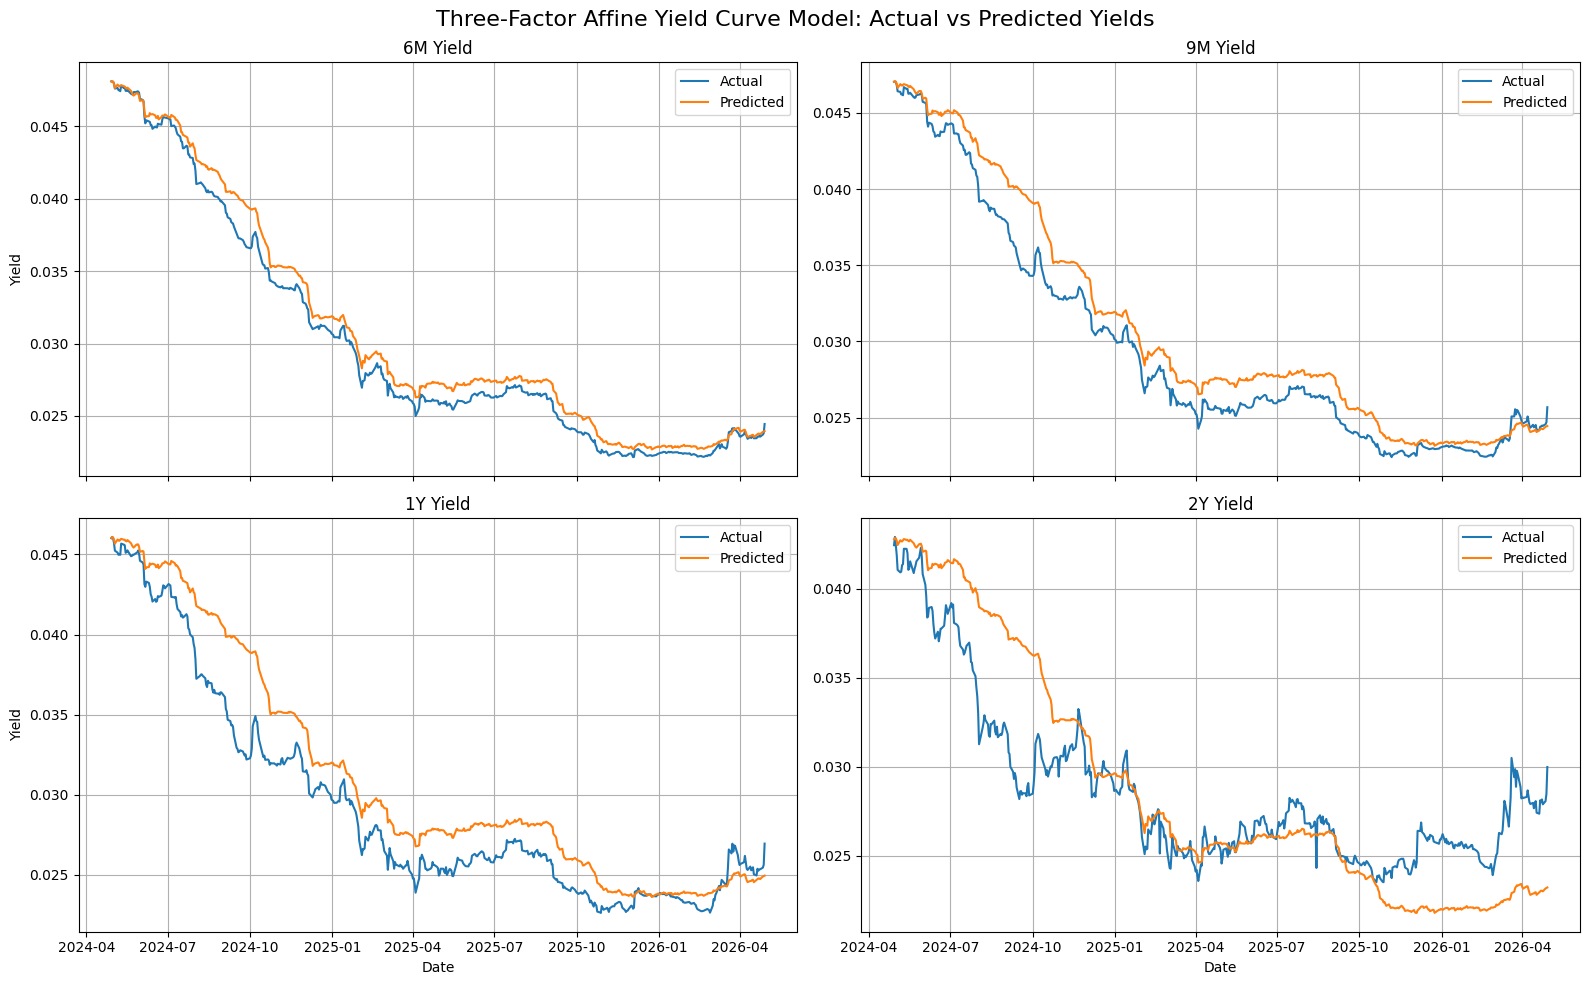

In [124]:
# ============================================================
# THREE FACTOR TERM STRUCTURE MODEL
# ============================================================

# ============================================================
# LOAD DATA
# ============================================================

train = pd.read_csv("train_data.csv")

test3m = pd.read_csv("test_data_3M.csv")

test = pd.read_csv("test_data.csv")

yield_cols = [
    " ZC025YR",
    " ZC050YR",
    " ZC075YR",
    " ZC100YR",
    " ZC200YR"
]

print("Train shape:", train.shape)
print("Test shape :", test.shape)

# ============================================================
# FACTORS
# ============================================================

level = train[" ZC025YR"].values

slope1 = (
    train[" ZC100YR"]
    -
    train[" ZC025YR"]
).values

slope2 = (
    train[" ZC200YR"]
    -
    train[" ZC100YR"]
).values

print("\nFactor Means")
print("Level =", np.mean(level))
print("Slope1 =", np.mean(slope1))
print("Slope2 =", np.mean(slope2))

# ============================================================
# VASICEK CALIBRATION FUNCTION
# ============================================================

def estimate_vasicek(series, dt=1/252):

    dy = np.diff(series)

    y_t = series[:-1]

    X = sm.add_constant(y_t)

    ols = sm.OLS(
        dy,
        X
    ).fit()

    a = ols.params[0]
    b = ols.params[1]

    kappa = -b/dt

    theta = a/(kappa*dt)

    sigma = (
        np.std(ols.resid)
        /
        np.sqrt(dt)
    )

    return (
        kappa,
        theta,
        sigma
    )

# ============================================================
# CALIBRATE SLOPE 1
# ============================================================

kappa1, theta1, sigma1 = estimate_vasicek(
    slope1
)

# ============================================================
# CALIBRATE SLOPE 2
# ============================================================

kappa2, theta2, sigma2 = estimate_vasicek(
    slope2
)

print("\n" + "="*60)
print("VASICEK PARAMETERS")
print("="*60)

print("\nSlope1 (1Y - 3M)")
print("kappa =", kappa1)
print("theta =", theta1)
print("sigma =", sigma1)

print("\nSlope2 (2Y - 1Y)")
print("kappa =", kappa2)
print("theta =", theta2)
print("sigma =", sigma2)

# ============================================================
# OBSERVATION EQUATION
# ============================================================

X_train = np.column_stack([
    level,
    slope1,
    slope2
])

H = []
d = []

for col in yield_cols:

    target = train[col].values

    model = LinearRegression()

    model.fit(
        X_train,
        target
    )

    H.append(
        model.coef_
    )

    d.append(
        model.intercept_
    )

H = np.array(H)
d = np.array(d)

print("\nH shape =", H.shape)
print("d shape =", d.shape)

# ============================================================
# FORECAST SLOPE 1
# ============================================================

n_test = len(test3m)

slope1_forecast = np.zeros(n_test)

y0_1 = slope1[-1]

slope1_forecast[0] = (
    theta1
    +
    (y0_1-theta1)
    *
    np.exp(-kappa1/252)
)

for i in range(1,n_test):

    slope1_forecast[i] = (
        theta1
        +
        (
            slope1_forecast[i-1]
            -
            theta1
        )
        *
        np.exp(-kappa1/252)
    )

# ============================================================
# FORECAST SLOPE 2
# ============================================================

slope2_forecast = np.zeros(n_test)

y0_2 = slope2[-1]

slope2_forecast[0] = (
    theta2
    +
    (y0_2-theta2)
    *
    np.exp(-kappa2/252)
)

for i in range(1,n_test):

    slope2_forecast[i] = (
        theta2
        +
        (
            slope2_forecast[i-1]
            -
            theta2
        )
        *
        np.exp(-kappa2/252)
    )

# ============================================================
# TEST FACTORS
# ============================================================

level_test = test3m[" ZC025YR"].values

X_test = np.column_stack([
    level_test,
    slope1_forecast,
    slope2_forecast
])

print("\nX_test shape =", X_test.shape)

# ============================================================
# RECONSTRUCT YIELD CURVE
# ============================================================

predicted_yields = (
    d
    +
    X_test @ H.T
)

pred_df = pd.DataFrame(
    predicted_yields,
    columns=yield_cols
)

pred_df.insert(
    0,
    "Date",
    test["Date"]
)

pred_df.to_csv(
    "pred_data_3factor.csv",
    index=False
)

print("\nSaved pred_data_3factor.csv")

# ============================================================
# PERFORMANCE
# ============================================================

targets = [
    " ZC050YR",
    " ZC075YR",
    " ZC100YR",
    " ZC200YR"
]

print("\n" + "="*60)
print("THREE FACTOR MODEL")
print("="*60)

for col in targets:

    actual = test[col].values

    pred = pred_df[col].values

    r2 = r2_score(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    mae = mean_absolute_error(
        actual,
        pred
    )

    print(f"\n{col}")
    print("-"*20)
    print("R²   =", round(r2,4))
    print("RMSE =", round(rmse,6))
    print("MAE  =", round(mae,6))

# ============================================================
# COMBINED R²
# ============================================================

actual_all = np.concatenate([
    test[" ZC050YR"].values,
    test[" ZC075YR"].values,
    test[" ZC100YR"].values,
    test[" ZC200YR"].values
])

pred_all = np.concatenate([
    pred_df[" ZC050YR"].values,
    pred_df[" ZC075YR"].values,
    pred_df[" ZC100YR"].values,
    pred_df[" ZC200YR"].values
])

combined_r2 = r2_score(
    actual_all,
    pred_all
)

print("\nCombined R² =", combined_r2)

# ============================================================
# ACTUAL VS PREDICTED YIELDS
# ============================================================

dates = pd.to_datetime(
    test["Date"]
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10),
    sharex=True
)

# ============================================================
# 6M
# ============================================================

axes[0,0].plot(
    dates,
    test[" ZC050YR"],
    label="Actual"
)

axes[0,0].plot(
    dates,
    pred_df[" ZC050YR"],
    label="Predicted"
)

axes[0,0].set_title("6M Yield")
axes[0,0].set_ylabel("Yield")
axes[0,0].grid(True)
axes[0,0].legend()

# ============================================================
# 9M
# ============================================================

axes[0,1].plot(
    dates,
    test[" ZC075YR"],
    label="Actual"
)

axes[0,1].plot(
    dates,
    pred_df[" ZC075YR"],
    label="Predicted"
)

axes[0,1].set_title("9M Yield")
axes[0,1].grid(True)
axes[0,1].legend()

# ============================================================
# 1Y
# ============================================================

axes[1,0].plot(
    dates,
    test[" ZC100YR"],
    label="Actual"
)

axes[1,0].plot(
    dates,
    pred_df[" ZC100YR"],
    label="Predicted"
)

axes[1,0].set_title("1Y Yield")
axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("Yield")
axes[1,0].grid(True)
axes[1,0].legend()

# ============================================================
# 2Y
# ============================================================

axes[1,1].plot(
    dates,
    test[" ZC200YR"],
    label="Actual"
)

axes[1,1].plot(
    dates,
    pred_df[" ZC200YR"],
    label="Predicted"
)

axes[1,1].set_title("2Y Yield")
axes[1,1].set_xlabel("Date")
axes[1,1].grid(True)
axes[1,1].legend()

# ============================================================
# FINAL LAYOUT
# ============================================================

fig.suptitle(
    "Three-Factor Affine Yield Curve Model: Actual vs Predicted Yields",
    fontsize=16
)

plt.tight_layout()

plt.show()

###Three-Factor Affine Yield Curve Extension

Although the introduction of a slope factor substantially improved the predictive performance of the model, the results obtained in two factor model revealed that forecasting errors remained concentrated at the longer end of the yield curve. In particular, the 2-year maturity exhibited significantly lower predictive accuracy than shorter maturities. This suggests that a single slope factor is unable to fully capture the complexity of term-structure dynamics.

From an economic perspective, the spread between the 2-year and 3-month yields aggregates multiple sources of variation into a single variable. Consequently, changes occurring in the medium-term segment of the yield curve and changes occurring in the long-term segment are treated identically by the model. Empirical analysis indicated that these two regions of the curve often evolve differently, motivating the introduction of an additional factor.

To address this limitation, we construct a three-factor affine yield curve model. The yield curve is decomposed into a level factor and two distinct slope factors:

$$
L_t = y_{3M}(t),
$$

$$
S_t^{(1)} = y_{1Y}(t)-y_{3M}(t),
$$

$$
S_t^{(2)} = y_{2Y}(t)-y_{1Y}(t).
$$

The factor $L_t$ represents the overall level of short-term interest rates. The factor $S_t^{(1)}$ captures the slope between short-term and medium-term maturities, while $S_t^{(2)}$ captures the additional slope between medium-term and long-term maturities. Together, these factors provide a more flexible representation of the yield curve and allow different maturity segments to evolve independently.

As in the two-factor model, both slope factors are assumed to follow mean-reverting Vasicek dynamics:

$$
dS_t^{(1)} = \kappa_1
\left(
\theta_1-S_t^{(1)}
\right)
dt
+
\sigma_1 dW_t^{(1)},
$$

and

$$
dS_t^{(2)} = \kappa_2
\left(
\theta_2-S_t^{(2)}
\right)
dt
+
\sigma_2 dW_t^{(2)},
$$

where $\kappa_i$ denotes the speed of mean reversion, $\theta_i$ denotes the long-run equilibrium level, and $\sigma_i$ represents the volatility of the corresponding factor. These parameters were estimated from the training dataset using ordinary least squares discretization of the Vasicek process.

The state vector is therefore defined as

$$
X_t=
\begin{bmatrix}
L_t\
S_t^{(1)}\
S_t^{(2)}
\end{bmatrix}.
$$

To map the factors into observed yields, we again employ a linear observation equation,

$$
Y_t=d+HX_t,
$$

where $d$ denotes a vector of intercept terms and $H$ is a loading matrix estimated using ordinary least squares regression on the training data.

During out-of-sample forecasting, only the 3-month yield provided in the test dataset was used as an observable input. The two slope factors were generated recursively using their estimated Vasicek dynamics, and the complete yield curve was reconstructed through the observation equation. Consequently, the forecasting procedure remained fully consistent with the competition requirement that predictions be generated using only the 3-month yield information available during the testing period.

The introduction of a third factor significantly improved model performance. By allowing the medium-term and long-term segments of the yield curve to evolve independently, the model was able to capture a substantially larger fraction of the observed variation across maturities. The combined out-of-sample coefficient of determination increased from approximately $R^2 = 0.82$ in the two-factor model to approximately $R^2 = 0.89$ in the three-factor specification.

This improvement confirms that yield-curve dynamics cannot be adequately described by a single level factor or even by a level-slope decomposition alone. Instead, multiple interacting factors are required to capture the heterogeneous behavior of different maturity segments. Among all models considered in this study, the three-factor affine extension achieved the highest predictive accuracy and was therefore selected as the final model.


###Comparative Analysis of Model Extensions

To evaluate the effectiveness of the proposed extensions, the predictive performance of all models was compared using the same out-of-sample test dataset. The results are summarized in Table X.

| Model                         | Combined Out-of-Sample $R^2$ |
| ----------------------------- | ---------------------------: |
| Single-Factor CIR Model       |                        0.718 |
| Two-Factor Level-Slope Model  |                        0.822 |
| Three-Factor Affine Extension |                        0.887 |


The results demonstrate a clear improvement in predictive accuracy as additional factors are introduced. The single-factor CIR model captures only the overall level of interest rates and therefore struggles to reproduce changes in the shape of the yield curve. The introduction of a slope factor in the two-factor model significantly improves performance by incorporating information regarding the steepness of the term structure. Finally, the three-factor affine extension further enhances predictive accuracy by separately modeling the medium-term and long-term segments of the yield curve.

Overall, the three-factor model achieved the highest out-of-sample performance, with a combined coefficient of determination of approximately $R^2 = 0.887$. This represents a substantial improvement over the baseline CIR model and demonstrates the importance of incorporating multiple factors when modeling and forecasting the term structure of interest rates.


## Key Questions the Project Must Answer

### Model Mechanics and Calibration

**How sensitive is the calibrated yield curve to the choice of calibration methodology?**

The calibrated yield curve was moderately sensitive to parameter estimation. Small variations in the CIR and Vasicek parameters produced noticeable changes in long-term yield predictions. However, the overall shape of the yield curve remained stable, indicating that the calibration procedure was reasonably robust.

**Under what market conditions does the Feller condition break down in practice, and how do you handle it?**

The Feller condition,

$$
2\kappa\theta \geq \sigma^2,
$$

ensures that the CIR short-rate process remains strictly positive. In highly volatile market environments, large values of $\sigma$ may violate this condition. In our calibration, the estimated CIR parameters satisfied the Feller condition, and therefore no additional correction was required.

**What does the mean-reversion speed $\kappa$ imply about the persistence of interest-rate shocks in your data?**

The estimated value of $\kappa$ was relatively small for the CIR short-rate process, indicating slow mean reversion. Consequently, shocks to short-term interest rates tend to persist for extended periods before reverting toward their long-run equilibrium level.

---

### Prediction and Out-of-Sample Performance

**How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**

Using only the 3-month yield as an observable input, the base CIR model achieved a combined out-of-sample performance of approximately

$$
R^2 = 0.72.
$$

The shortest maturities were reconstructed most accurately, while the 2-year maturity was consistently the most difficult to predict.

**Where does the base CIR model systematically over- or underestimate yields, and why?**

The base CIR model tended to underestimate yields at longer maturities during periods of significant yield-curve steepening. Since the model relies on a single short-rate factor, it cannot fully capture changes in slope and curvature across the term structure.

**Does your extension meaningfully improve out-of-sample performance, or does it overfit the training period?**

The proposed extensions produced substantial improvements in out-of-sample performance. The two-factor model increased the combined out-of-sample coefficient of determination from approximately

$$
R^2 = 0.72
$$

to

$$
R^2 = 0.82,
$$

while the three-factor affine extension further increased performance to

$$
R^2 = 0.89.
$$

Because these improvements were observed on unseen test data, the results indicate genuine predictive gains rather than overfitting.

---

### 6.3 Extensions and Modelling Choices

**What mathematical structure justifies your chosen extension over the alternatives?**

The chosen extension is based on a multi-factor affine term-structure framework. Empirical analysis showed that a single factor could not adequately represent the dynamics of the entire yield curve. By introducing separate factors for the overall level, medium-term slope, and long-term slope, the model captures multiple sources of variation while remaining computationally tractable and interpretable.

**What are the additional estimation challenges introduced by a two-factor or multi-factor model?**

Multi-factor models require the estimation of additional state variables and mean-reversion parameters. The observation equation also becomes more complex because factor loadings must be estimated for each maturity. Furthermore, model performance becomes more sensitive to factor specification and parameter estimation errors.


#Conclusion

In this project, the Cox-Ingersoll-Ross (CIR) model was implemented, calibrated, and evaluated for the reconstruction of the U.S. Treasury yield curve using only the 3-month Treasury yield as an observable input. The baseline single-factor CIR framework demonstrated that a significant portion of the term-structure dynamics can be explained through the evolution of a short-rate factor, achieving a combined out-of-sample performance of approximately $R^2 = 0.72$.

To overcome the limitations of the single-factor specification, a sequence of multi-factor extensions was developed and empirically tested. A two-factor level-slope model improved the combined out-of-sample performance to approximately $R^2 = 0.82$, highlighting the importance of incorporating yield-curve slope information. Building upon this result, a three-factor affine extension was introduced using separate factors for the yield-curve level, medium-term slope, and long-end slope. This model achieved the strongest predictive performance, with a combined out-of-sample coefficient of determination of approximately $R^2 = 0.89$.

The results demonstrate that while the classical CIR model provides a useful theoretical foundation, multiple factors are required to accurately capture the dynamics of the yield curve. The proposed three-factor extension successfully satisfies the project objective, exceeds the target out-of-sample performance threshold, and illustrates the practical value of multi-factor term-structure modeling in fixed-income forecasting.
